# Python para Clustering



#Laboratorio 8

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/CUARTO CICLO/Analitica para la Resolucion de Problemas/MATERIAL/CC GENERAL.csv')
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


In [ ]:
df_inicial = pd.read_csv('/content/drive/MyDrive/CUARTO CICLO/Analitica para la Resolucion de Problemas/MATERIAL/CC GENERAL.csv')
df_inicial.isnull().sum()

,0
CUST_ID,0
BALANCE,0
BALANCE_FREQUENCY,0
PURCHASES,0
ONEOFF_PURCHASES,0
INSTALLMENTS_PURCHASES,0
CASH_ADVANCE,0
PURCHASES_FREQUENCY,0
ONEOFF_PURCHASES_FREQUENCY,0
PURCHASES_INSTALLMENTS_FREQUENCY,0


LIMPIEZA DE DATOS



Durante el análisis se identificaron valores nulos en las columnas CREDIT_LIMIT y MINIMUM_PAYMENTS. Estos valores vacíos pueden afectar el rendimiento del modelo y generar resultados incorrectos durante la segmentación de clientes.

Para solucionar este problema, se decidió reemplazar los valores nulos utilizando la mediana de cada columna. Se utilizó la mediana porque el dataset contiene datos financieros con valores extremos, y esta medida representa de mejor manera el comportamiento central de los datos sin verse afectada por montos muy altos o muy bajos.



In [ ]:


# Rellenar con la mediana
df['CREDIT_LIMIT'].fillna(df['CREDIT_LIMIT'].median(), inplace=True)

df['MINIMUM_PAYMENTS'].fillna(df['MINIMUM_PAYMENTS'].median(), inplace=True)

/tmp/ipykernel_1198/1961856031.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['CREDIT_LIMIT'].fillna(df['CREDIT_LIMIT'].median(), inplace=True)
/tmp/ipykernel_1198/1961856031.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, 

Después de realizar la imputación, el dataset quedó completo y listo para el proceso de análisis y clustering.

In [ ]:
# Verificar nuevamente
print(df.isnull().sum())

CUST_ID                             0
BALANCE                             0
BALANCE_FREQUENCY                   0
PURCHASES                           0
ONEOFF_PURCHASES                    0
INSTALLMENTS_PURCHASES              0
CASH_ADVANCE                        0
PURCHASES_FREQUENCY                 0
ONEOFF_PURCHASES_FREQUENCY          0
PURCHASES_INSTALLMENTS_FREQUENCY    0
CASH_ADVANCE_FREQUENCY              0
CASH_ADVANCE_TRX                    0
PURCHASES_TRX                       0
CREDIT_LIMIT                        0
PAYMENTS                            0
MINIMUM_PAYMENTS                    0
PRC_FULL_PAYMENT                    0
TENURE                              0
dtype: int64


In [ ]:
# Verificar filas duplicadas
duplicados = df.duplicated().sum()

print("Cantidad de filas duplicadas:", duplicados)

Cantidad de filas duplicadas: 0


# Análisis Exploratorio de Datos

Antes de aplicar el modelo de clustering, se realizó un análisis exploratorio de datos con el objetivo de comprender mejor el comportamiento de las variables financieras del dataset.


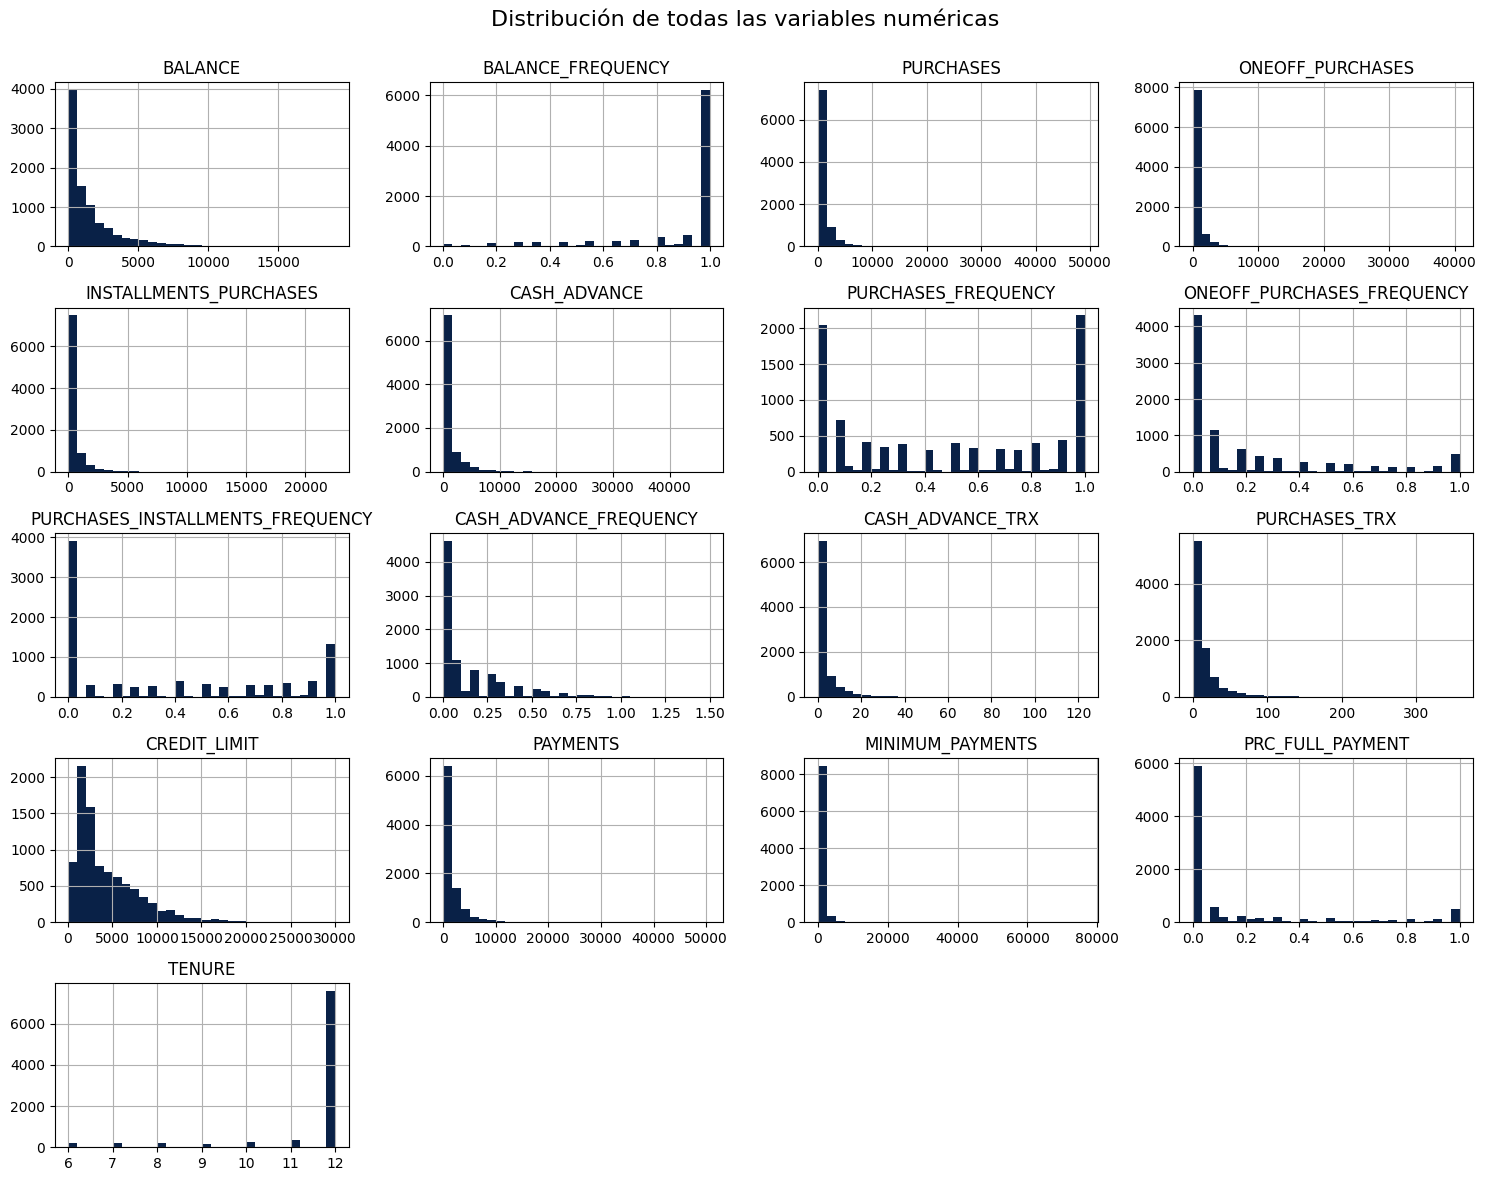

In [ ]:
num_cols = df.select_dtypes(include=[np.number]).columns

# Histogramas con color personalizado
df[num_cols].hist(
    figsize=(15, 12),
    bins=30,
    color='#092147'
)

# Título general
plt.suptitle("Distribución de todas las variables numéricas", size=16)

# Ajuste de espacios
plt.tight_layout(rect=[0, 0, 1, 0.98])

plt.show()

Como parte del análisis exploratorio de datos, se evaluó la correlación entre las variables numéricas del dataset financiero.

Para ello se utilizó un mapa de calor (heatmap), el cual permitió identificar relaciones entre variables relacionadas con compras, pagos, límites de crédito y avances en efectivo.

Este análisis ayudó a comprender mejor el comportamiento financiero de los clientes y detectar variables con relaciones fuertes antes de aplicar el modelo de clustering.

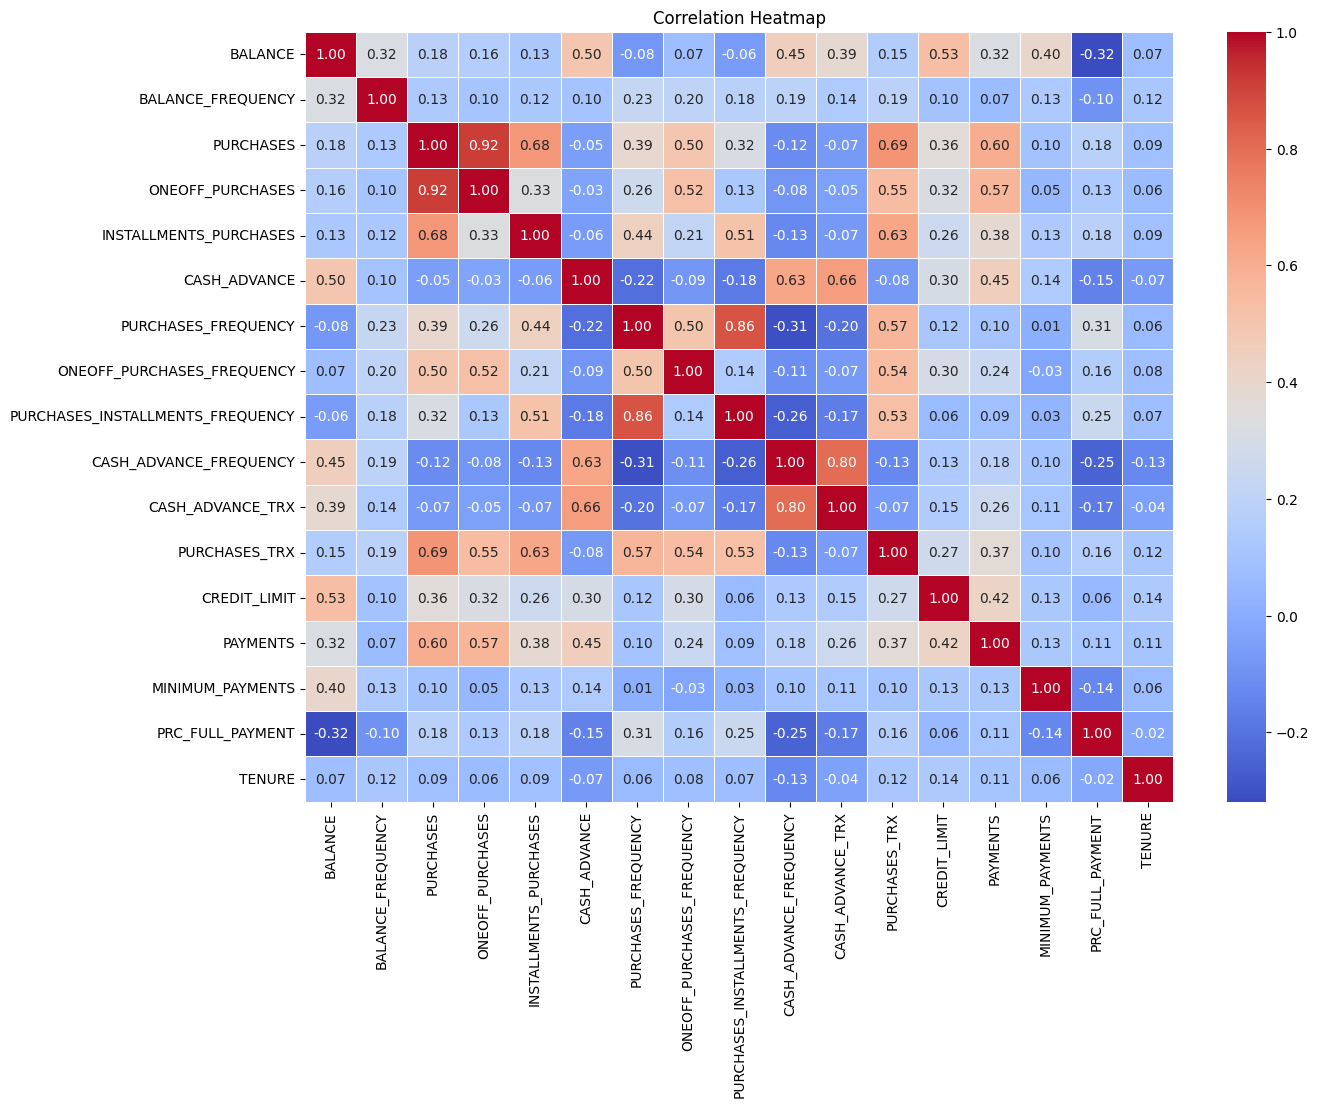

In [ ]:
num_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(14,10))

sns.heatmap(num_df.corr(),
            annot=True,          # Mostrar valores
            fmt=".2f",           # Mostrar 2 decimales
            cmap='coolwarm',
            linewidths=0.5)

plt.title("Correlation Heatmap")

plt.show()

## Detección de Valores Atípicos

Se utilizaron diagramas de caja (boxplots) para identificar posibles valores atípicos en las variables financieras del dataset.

Este análisis permitió observar la dispersión de los datos y detectar clientes con comportamientos financieros extremos, como montos de compras o límites de crédito significativamente superiores al promedio.

La identificación de outliers es importante porque el algoritmo K-Means puede verse afectado por valores extremos durante la formación de los clusters.

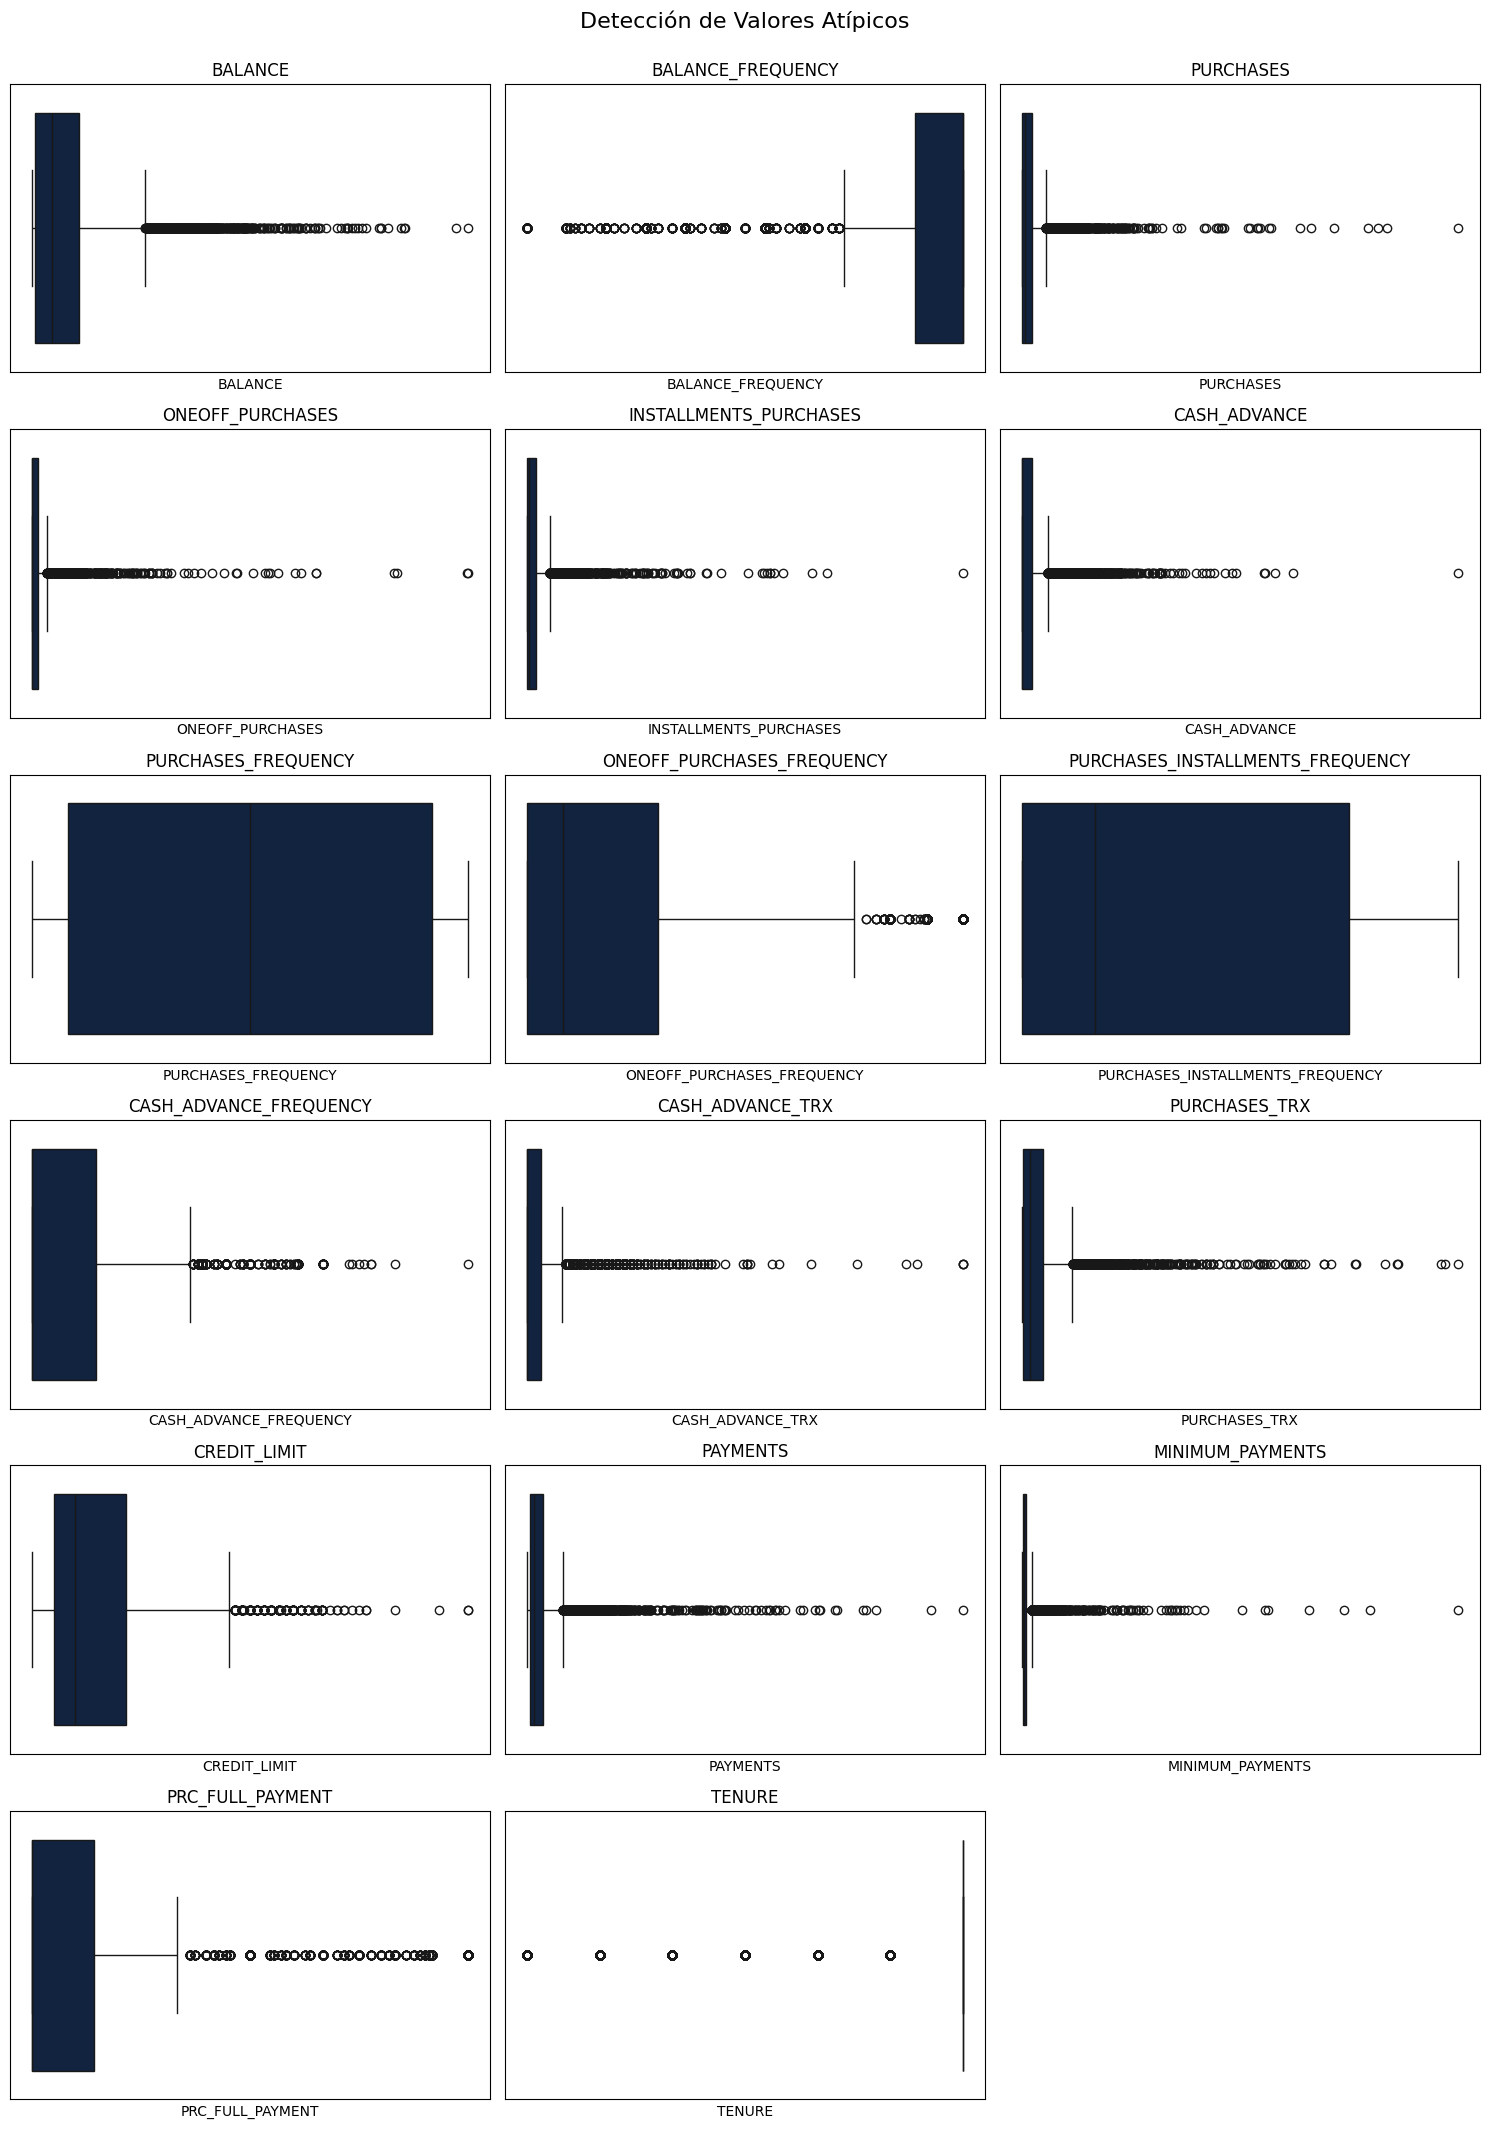

In [ ]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(15, 25))

# Título general
plt.suptitle("Detección de Valores Atípicos", size=16)

for i, col in enumerate(numerical_cols, 1):

    plt.subplot(7, 3, i)

    # Boxplot con color personalizado
    sns.boxplot(
        x=df[col],
        color='#092147'
    )

    # Quitar números de los ejes
    plt.xticks([])
    plt.yticks([])

    # Título de cada gráfico
    plt.title(col)

# Ajustar espacios
plt.tight_layout(rect=[0, 0, 1, 0.98])

plt.show()

#Paso 2: Estandarización de Datos

Las variables del dataset presentan diferentes escalas y unidades, ya que algunas representan montos financieros elevados y otras corresponden a frecuencias o porcentajes.

Por ello, se aplicó una estandarización utilizando StandardScaler, con el objetivo de transformar todas las variables a una misma escala y evitar que aquellas con valores más grandes influyan de manera desproporcionada en el algoritmo K-Means.

Este proceso permitió que todas las variables tuvieran la misma importancia durante el cálculo de distancias y la formación de clusters.


In [ ]:
from sklearn.preprocessing import StandardScaler

# Seleccionar solo columnas numéricas
df_numeric = df.select_dtypes(include=['float64', 'int64'])

# Escalamiento
scaler = StandardScaler()

df_scaled = pd.DataFrame(
    scaler.fit_transform(df_numeric),
    columns=df_numeric.columns
)

print(df_scaled.head())

    BALANCE  BALANCE_FREQUENCY  PURCHASES  ONEOFF_PURCHASES  \
0 -0.731989          -0.249434  -0.424900         -0.356934   
1  0.786961           0.134325  -0.469552         -0.356934   
2  0.447135           0.518084  -0.107668          0.108889   
3  0.049099          -1.016953   0.232058          0.546189   
4 -0.358775           0.518084  -0.462063         -0.347294   

   INSTALLMENTS_PURCHASES  CASH_ADVANCE  PURCHASES_FREQUENCY  \
0               -0.349079     -0.466786            -0.806490   
1               -0.454576      2.605605            -1.221758   
2               -0.454576     -0.466786             1.269843   
3               -0.454576     -0.368653            -1.014125   
4               -0.454576     -0.466786            -1.014125   

   ONEOFF_PURCHASES_FREQUENCY  PURCHASES_INSTALLMENTS_FREQUENCY  \
0                   -0.678661                         -0.707313   
1                   -0.678661                         -0.916995   
2                    2.673451      

# Paso 4: Aplicación del Modelo K-Means

Se aplicó el algoritmo K-Means para agrupar automáticamente a los clientes según similitudes en su comportamiento financiero.

In [ ]:
# Modelo inicial
kmeans = KMeans(n_clusters=3, random_state=42)

cluster_labels = kmeans.fit_predict(df_scaled)

# Silhouette
sil_score = silhouette_score(df_scaled, cluster_labels)

print("Coeficiente de silueta:", sil_score)

Coeficiente de silueta: 0.20671817817880617


# Paso 4.1: Método del Codo (WSS)

Para determinar la cantidad óptima de clusters se utilizó el método del codo.

Este método evalúa la suma de cuadrados intra-cluster (WSS) para diferentes valores de K. El objetivo es identificar el punto donde la disminución del error comienza a estabilizarse, formando un “codo” en la gráfica.

Ese punto representa la mejor cantidad de clusters.

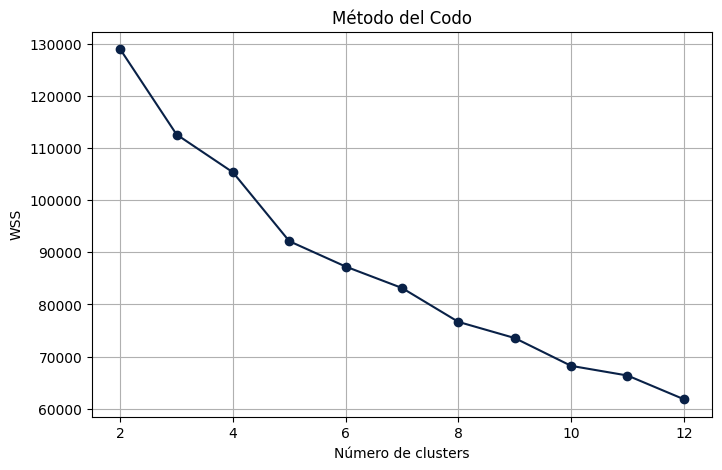

In [ ]:
wss = []

for k in range(2, 13):

    km = KMeans(n_clusters=k, random_state=42)

    km.fit(df_scaled)

    wss.append(km.inertia_)

plt.figure(figsize=(8,5))

plt.plot(range(2,13),
         wss,
         marker='o',
         color='#092147')

plt.xlabel('Número de clusters')

plt.ylabel('WSS')

plt.title('Método del Codo')

plt.grid(True)

plt.show()

# Paso 4.2: Método de Silueta
Explicación

También se utilizó el coeficiente de silueta para evaluar la calidad de los clusters generados.

Esta métrica mide qué tan similares son los clientes dentro de un mismo grupo y qué tan diferentes son respecto a otros clusters.

Mientras más cercano sea el valor a 1, mejor será la separación entre grupos.

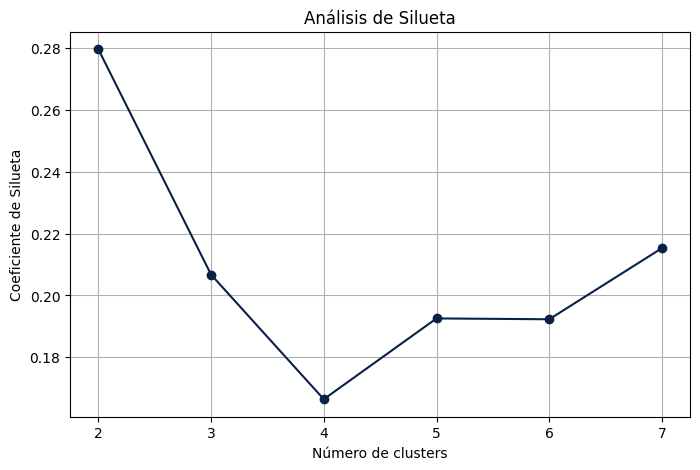

In [ ]:
sil_scores = []

for k in range(2, 8):

    km = KMeans(n_clusters=k, random_state=42)

    labels = km.fit_predict(df_scaled)


    score = silhouette_score(df_scaled, labels)

    sil_scores.append(score)

plt.figure(figsize=(8,5))

plt.plot(range(2,8),
         sil_scores,
         marker='o',
         color='#092147')

plt.xlabel('Número de clusters')

plt.ylabel('Coeficiente de Silueta')

plt.title('Análisis de Silueta')

plt.grid(True)

plt.show()

# Paso 4.1.3: Método Calinski-Harabasz
Se utilizó el índice de Calinski-Harabasz. Este indicador evalúa la separación entre clusters y la compactación interna de los grupos. Un valor más alto indica una mejor segmentación de los datos.

El objetivo es seleccionar el número de clusters que maximice este índice.

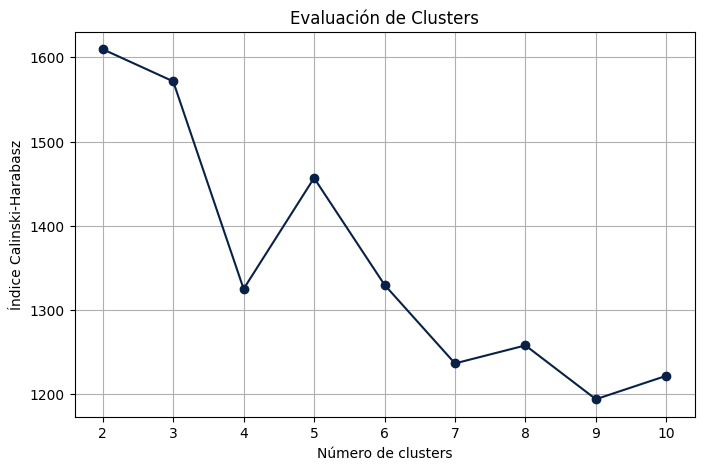

In [ ]:
from sklearn.metrics import calinski_harabasz_score

ch_scores = []

for k in range(2, 11):

    km = KMeans(
        n_clusters=k,
        random_state=42
    )

    labels = km.fit_predict(df_scaled)

    score = calinski_harabasz_score(
    df_scaled,
    labels
)

    ch_scores.append(score)

# Gráfico
plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    ch_scores,
    marker='o',
    color='#092147'
)

plt.xlabel('Número de clusters')

plt.ylabel('Índice Calinski-Harabasz')

plt.title('Evaluación de Clusters')

plt.grid(True)

plt.show()

In [ ]:
#predict clusters
kmeans = KMeans(n_clusters=3, n_init=10, random_state=42)

kmeans_clusters = kmeans.fit_predict(df_pca)

In [ ]:
# Distribución de clusters
unique, counts = np.unique(kmeans_clusters, return_counts=True)

print("Cluster distribution:", dict(zip(unique, counts)))

# Silhouette final
score = silhouette_score(df_pca, kmeans_clusters)

print("Silhouette Score:", score)

Cluster distribution: {np.int32(0): np.int64(1510), np.int32(1): np.int64(1202), np.int32(2): np.int64(6238)}
Silhouette Score: 0.45638162893179396


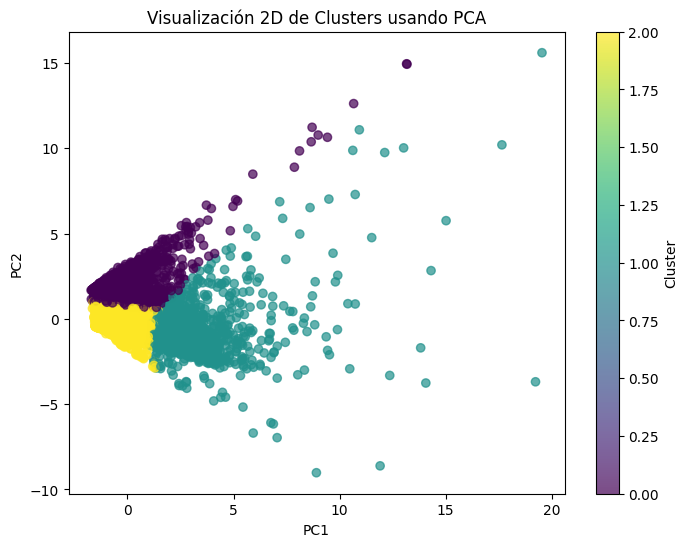

In [ ]:
# =========================
# VISUALIZACIÓN 2D
# =========================

plt.figure(figsize=(8,6))

plt.scatter(
    df_pca.iloc[:,0],
    df_pca.iloc[:,1],
    c=kmeans_clusters,
    cmap='viridis',
    alpha=0.7
)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title("Visualización 2D de Clusters usando PCA")

plt.colorbar(label='Cluster')

plt.show()

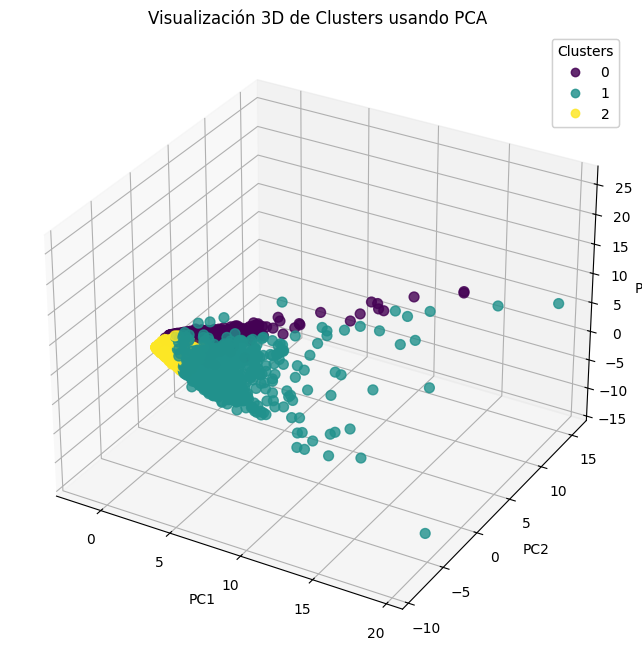

In [ ]:
# =========================
# VISUALIZACIÓN 3D
# =========================

from mpl_toolkits.mplot3d import Axes3D

x = df_pca.iloc[:, 0]
y = df_pca.iloc[:, 1]
z = df_pca.iloc[:, 2]

fig = plt.figure(figsize=(10,8))

ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    x,
    y,
    z,
    s=50,
    c=kmeans_clusters,
    cmap='viridis',
    alpha=0.8
)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")

ax.set_title("Visualización 3D de Clusters usando PCA")

legend = ax.legend(
    *scatter.legend_elements(),
    title="Clusters"
)

ax.add_artist(legend)

plt.show()

In [ ]:
# Modelo final

kmeans_final = KMeans(
    n_clusters=3,
    random_state=42
)

clusters = kmeans_final.fit_predict(df_scaled)

# Agregar clusters al dataframe original
df['cluster'] = clusters

print(df[['CUST_ID', 'cluster']].head())

  CUST_ID  cluster
0  C10001        1
1  C10002        0
2  C10003        2
3  C10004        1
4  C10005        1


In [ ]:
#find the best silhouette score

for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, n_init='auto', random_state=42)

    predict = kmeans.fit_predict(df_pca)

    score = silhouette_score(df_pca, predict)

    print(f"k={k}, Silhouette Score={score}")

k=2, Silhouette Score=0.5716659354415851
k=3, Silhouette Score=0.5163199686672633
k=4, Silhouette Score=0.518024506115402
k=5, Silhouette Score=0.5065898551784853
k=6, Silhouette Score=0.5037511836837117
k=7, Silhouette Score=0.4107305525899482
k=8, Silhouette Score=0.4154575187947819
k=9, Silhouette Score=0.42243966655305715


In [ ]:
#find the best silhouette score

for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, n_init='auto', random_state=42)
    predict = kmeans.fit_predict(df_pca)

    score = silhouette_score(df_pca, predict)
    print(f"k={k}, Silhouette Score={score}")

k=2, Silhouette Score=0.5612355366568221
k=3, Silhouette Score=0.5028331313112964
k=4, Silhouette Score=0.45412917248918033
k=5, Silhouette Score=0.44657543299968283
k=6, Silhouette Score=0.44620261111305365
k=7, Silhouette Score=0.3895727755605444
k=8, Silhouette Score=0.4088552080631071
k=9, Silhouette Score=0.40757866593487335


In [ ]:
#predict clusters
kmeans = KMeans(n_clusters=3, n_init=10, random_state=42)

kmeans_clusters = kmeans.fit_predict(df_pca)


unique, counts = np.unique(kmeans_clusters, return_counts=True)
print("Cluster distribution:", dict(zip(unique, counts)))


score = silhouette_score(df_pca,kmeans_clusters)
print("Silhouette Score:", score)


Cluster distribution: {np.int32(0): np.int64(1510), np.int32(1): np.int64(1202), np.int32(2): np.int64(6238)}
Silhouette Score: 0.45638162893179396


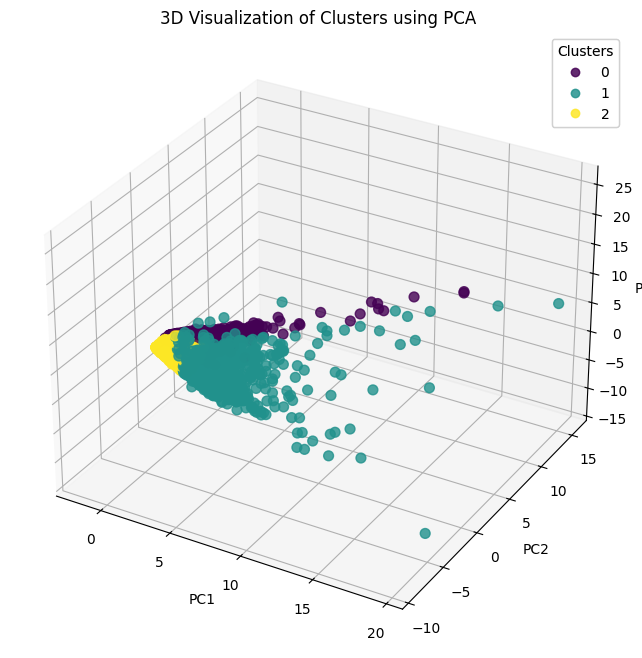

In [ ]:
#3D Visualization of Clusters using PCA

x = df_pca.iloc[:, 0]   # PC1
y = df_pca.iloc[:, 1]   # PC2
z = df_pca.iloc[:, 2]   # PC3

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter( x, y, z, s=50, c=kmeans_clusters, cmap='viridis', alpha=0.8)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("3D Visualization of Clusters using PCA")

legend = ax.legend(*scatter.legend_elements(), title="Clusters")
ax.add_artist(legend)

plt.show()

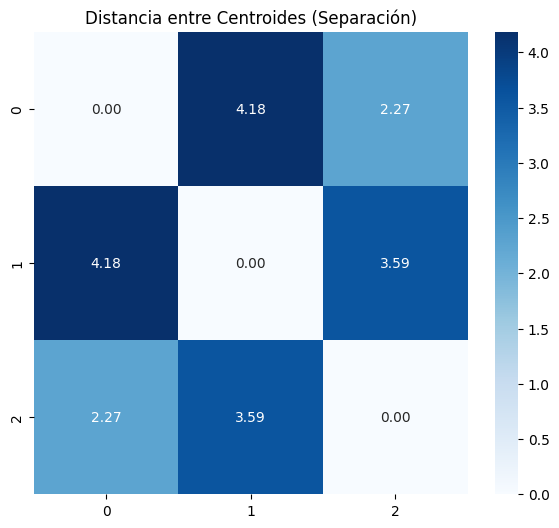

Coeficiente de Silueta: 0.13274012796084902
Índice Davies-Bouldin: 2.257726575655886


In [ ]:
from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score
from sklearn.metrics import pairwise_distances
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Distancia entre centroides
centroids = kmeans.cluster_centers_

distancias = pairwise_distances(centroids)

# Heatmap
plt.figure(figsize=(7,6))

sns.heatmap(distancias,
            annot=True,
            cmap='Blues',
            fmt=".2f")

plt.title("Distancia entre Centroides (Separación)")

plt.show()

# Métricas
silhouette = silhouette_score(data_scaled, clusters)

davies = davies_bouldin_score(data_scaled, clusters)

print("Coeficiente de Silueta:", silhouette)

print("Índice Davies-Bouldin:", davies)